Imports

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,median_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi']=110
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)


In [4]:
data=pd.read_csv('mpg.csv')
data.head(5)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
data.tail(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


Understanding Data

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB


In [30]:
df_clean=(
    data
    .drop(columns=['origin','car name'])
    .dropna()
    .reset_index(drop=True)
)

df_clean['horsepower'] = pd.to_numeric(
    df_clean['horsepower'],
    errors='coerce'
)

df_clean = (
    df_clean
    .dropna()
    .reset_index(drop=True)
)

df_clean.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [31]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.6 KB


In [8]:
df_clean.columns.tolist()

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year']

In [9]:
TARGET ='mpg'

QUANTITATIVE_CANDIDATES =[
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year']

In [10]:
TARGET

'mpg'

In [11]:
QUANTITATIVE_CANDIDATES

['cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year']

In [12]:
df_clean.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


EDA - Exploratory Data Analysis

In [13]:
cols =[TARGET]+QUANTITATIVE_CANDIDATES

cols

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year']

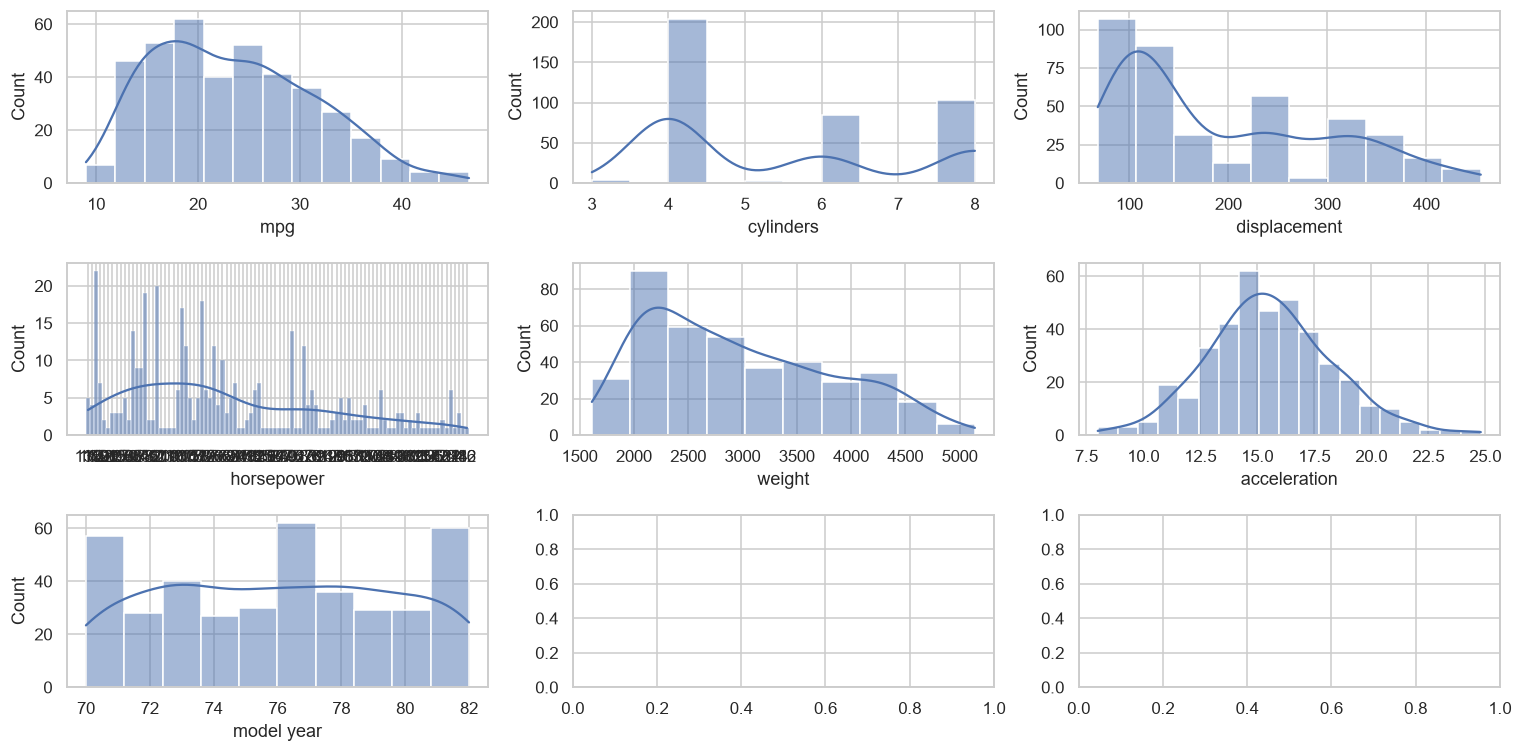

In [14]:
fig,axis=plt.subplots(3,3, figsize=(14,7))
axis=axis.ravel()

for i,c in enumerate(cols):
    sns.histplot(df_clean[c],ax=axis[i],kde=True)
plt.tight_layout()
plt.show()


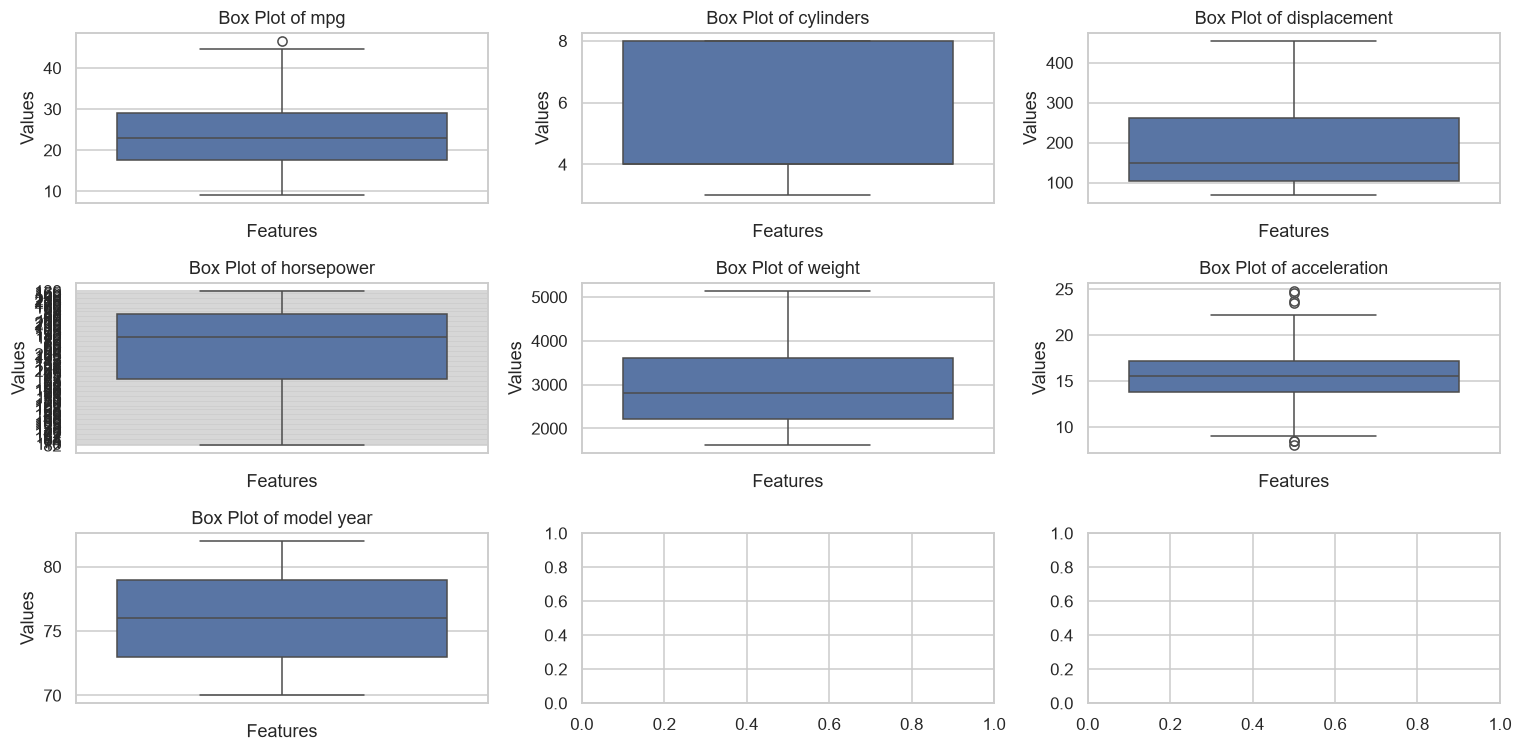

In [24]:
fig,axis=plt.subplots(3,3, figsize=(14,7))
axis=axis.ravel()

for i,c in enumerate(cols):
    sns.boxplot(data=df_clean[c],ax=axis[i])
    axis[i].set_title(f"Box Plot of {c}")
    axis[i].set_xlabel("Features")
    axis[i].set_ylabel("Values")
plt.tight_layout()
plt.show()

Bi-variate analysis

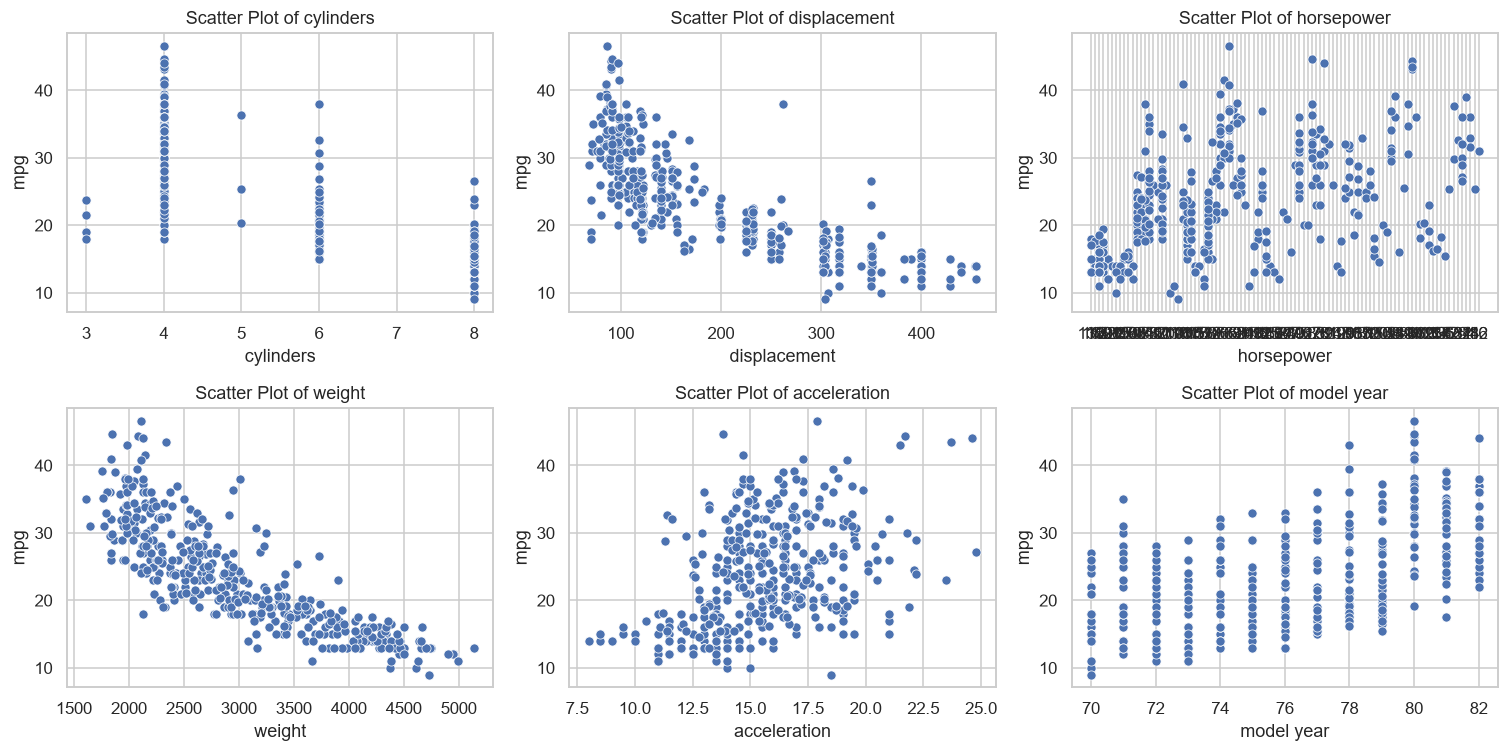

In [26]:

fig,axis=plt.subplots(2,3, figsize=(14,7))
axis=axis.ravel()

x_values =QUANTITATIVE_CANDIDATES

for i,c in enumerate(x_values):
    sns.scatterplot(data=df_clean,x=c,y=TARGET,ax=axis[i])
    axis[i].set_title(f"Scatter Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

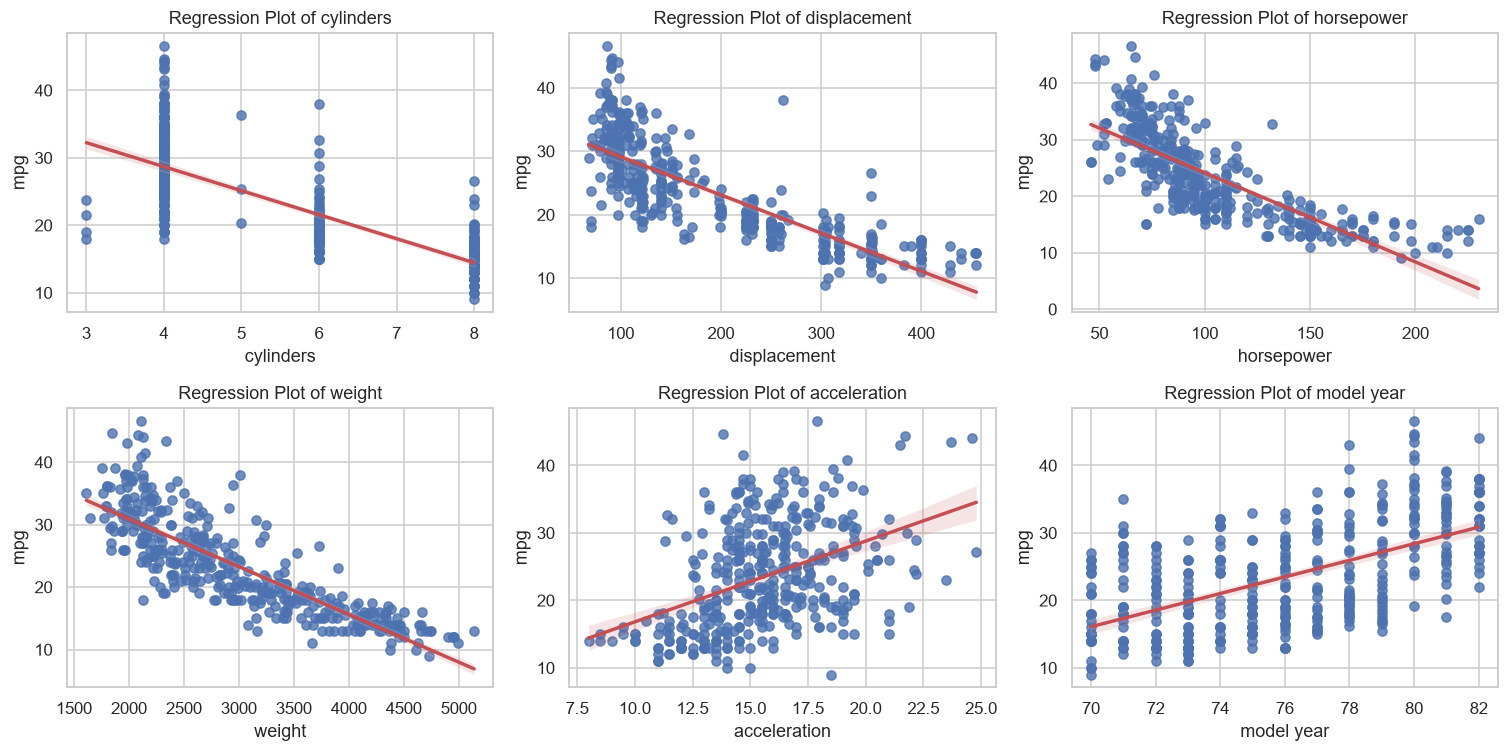

In [32]:
fig,axis=plt.subplots(2,3, figsize=(14,7))
axis=axis.ravel()

x_values =QUANTITATIVE_CANDIDATES

for i,c in enumerate(x_values):
    sns.regplot(data=df_clean,x=c,y=TARGET,ax=axis[i],line_kws=dict(color="r"))
    axis[i].set_title(f"Regression Plot of {c}")
    axis[i].set_xlabel(c)
    axis[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

Correlation Analysis

In [33]:
df_clean.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


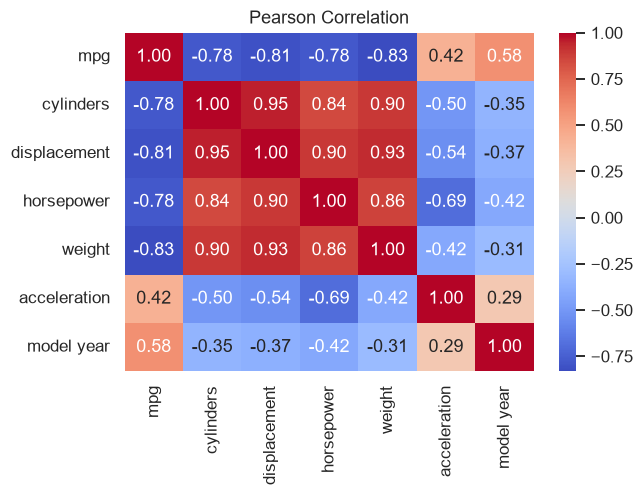

In [36]:

plt.figure(figsize=(6,4))
sns.heatmap(df_clean.corr(),annot=True,fmt=".2f",cmap="coolwarm",cbar=True)
plt.title("Pearson Correlation")
plt.show()

In [37]:
X=df_clean[QUANTITATIVE_CANDIDATES].values
Y=df_clean[TARGET].values

In [ ]:
train_size=0.8
test_size=0.2

x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=train_size,test_size=test_size,random_state=42)


In [39]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0.09, 0. ,-0.01,-0.01, 0.06, 0.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-12.38
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[13964.62, 653.62, 274.19, 52.76, 28.86, 8.35]"


In [40]:
y_pred=model.predict(x_test)

In [41]:
eval=root_mean_squared_error(y_pred=y_pred,y_true=y_test)

eval

3.1898530578438993